In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
from math import *

In [2]:
# Argument : the folder path 
# Return : an array of all images readed by OpenCV
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename), 0) # Gray Color converting
        if img is not None:
            images.append(img)
    return np.array(images)

In [3]:
def points_poly(contour):
    peri = cv2.arcLength(contour,True)
    vertices = cv2.approxPolyDP(contour,0.008*peri,True)
    return vertices

In [5]:
def bresenham(start, end):
    """Bresenham's Algorithm
    Produces a list of tuples from start and end
 
    >>> points1 = get_line((0, 0), (3, 4))
    >>> points2 = get_line((3, 4), (0, 0))
    >>> assert(set(points1) == set(points2))
    >>> print points1
    [(0, 0), (1, 1), (1, 2), (2, 3), (3, 4)]
    >>> print points2
    [(3, 4), (2, 3), (1, 2), (1, 1), (0, 0)]
    """
    # Setup initial conditions
    x1, y1 = start
    x2, y2 = end
    dx = x2 - x1
    dy = y2 - y1
 
    # Determine how steep the line is
    is_steep = abs(dy) > abs(dx)
 
    # Rotate line
    if is_steep:
        x1, y1 = y1, x1
        x2, y2 = y2, x2
 
    # Swap start and end points if necessary and store swap state
    swapped = False
    if x1 > x2:
        x1, x2 = x2, x1
        y1, y2 = y2, y1
        swapped = True
 
    # Recalculate differentials
    dx = x2 - x1
    dy = y2 - y1
 
    # Calculate error
    error = int(dx / 2.0)
    ystep = 1 if y1 < y2 else -1
 
    # Iterate over bounding box generating points between start and end
    y = y1
    points = []
    for x in range(x1, x2 + 1):
        coord = (y, x) if is_steep else (x, y)
        points.append(coord)
        error -= abs(dy)
        if error < 0:
            y += ystep
            error += dx
 
    # Reverse the list if the coordinates were swapped
    if swapped:
        points.reverse()
    return points

In [135]:
def tracer_composante(points):
        nbr_points = len(points)
        print("\n")
        composante = []
        for i in range(0,nbr_points-1):
            p1 = points[i][0]
            p2 = points[i+1][0]
            composante.append(bresenham(p1,p2))
        composante.append(bresenham(points[-1][0],points[0][0]))
        return composante

Nombre de points du ROI n° 0
12
[[[777 283]]

 [[778 285]]

 [[790 285]]

 [[791 284]]

 [[797 284]]

 [[802 280]]

 [[806 280]]

 [[806 278]]

 [[802 275]]

 [[800 276]]

 [[783 275]]

 [[780 278]]]
Coordonnées des points du composants n° 0 : 


[[(777, 283), (777, 284), (778, 285)], [(778, 285), (779, 285), (780, 285), (781, 285), (782, 285), (783, 285), (784, 285), (785, 285), (786, 285), (787, 285), (788, 285), (789, 285), (790, 285)], [(790, 285), (791, 284)], [(791, 284), (792, 284), (793, 284), (794, 284), (795, 284), (796, 284), (797, 284)], [(797, 284), (798, 283), (799, 282), (800, 282), (801, 281), (802, 280)], [(802, 280), (803, 280), (804, 280), (805, 280), (806, 280)], [(806, 280), (806, 279), (806, 278)], [(806, 278), (805, 277), (804, 276), (803, 276), (802, 275)], [(802, 275), (801, 276), (800, 276)], [(800, 276), (799, 276), (798, 276), (797, 276), (796, 276), (795, 276), (794, 276), (793, 276), (792, 276), (791, 275), (790, 275), (789, 275), (788, 275), (787, 275), (

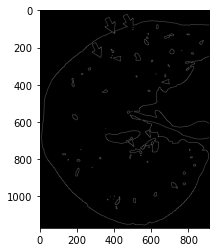

In [136]:
images = load_images_from_folder("./Ressources/test")
threshold_area_min = 200 # Réfléchir à l'utilisation d'un pourcentage de l'image ou utiliser des connaissances apriori de l'image 
threshold_max_point = 13
for image in images:  
    
    #Inverting image
    #image = cv2.bitwise_not(image);
    # Denoising the image
    image = cv2.GaussianBlur(image, (5, 5), 3)
    
    # Binarisation
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY) # Ne detecte que les flèches noires, il faut modifier le param 2 et 3 pour inverser cela et ajouter l'inverse de l'image
        
    # Contours Detection
    edged = cv2.Canny(binary,10,200) # Vérifier les paramètres entrés
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Get only extreme points of the contours
    
    # Sort the contours by area and then remove the largest frame contour
    n = len(contours)-1
    contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]
    num = 0

    for contour in contours:
        
        x,y,w,h = cv2.boundingRect(contour)
        hull = cv2.convexHull(contour)
        
        # ROI Extraction after area filtering
        area = cv2.contourArea(contour)
        points = points_poly(contour)
        nbr_points = len(points)
   
        if (area > threshold_area_min)&(nbr_points <13):

            print("Nombre de points du ROI n°",num)
            print(nbr_points)
            print(points)
            print(f"Coordonnées des points du composants n° {num} : ")
            print(tracer_composante(points))
            ROI = image[y:y+h, x:x+w]
            cv2.imwrite('./resultats/petitTestInverse/ROI_{}.png'.format(num), ROI)
            num += 1
    cv2.drawContours(image,contour,-1,(0,255,0),1)
    plt.imshow(edged,cmap='gray')
            

In [113]:
arrayTest = np.zeros(shape = (1,2),dtype = int)
A = np.array([8,9])
arrayTest = np.vstack((arrayTest,A))
print(arrayTest)
#bresenham(arrayTest[0],arrayTest[1])
B = np.empty(shape = (1,))


[[0 0]
 [8 9]]
